<img src="./graphics/explainability_vs_performance_black_box.png" align="left">

# Why explainable models?
## As models get more complex...
+ they gain flexibilty (aka capacity) and can be more accurate if they are not over-fitted.
+ they lose the ability to generate a straightforward explanation for how inputs map to outputs *(and start looking more and more like a black box...)*


## Decision trees vs. neural networks

We'll start with by building a decision tree (DT) classifier to classify income levels based on multiple features including `age`, `education level`, and `hours worked per week`, and extract the learned rules that explain the decision. We'll then, compare its performance with a neural network (NN) classifier (MLPClassifier) trained on the same data.


In [1]:
import pandas as pd

df_income = pd.read_csv('./data/adult_income.csv')
df_income.info()  # no missing values
df_income.head()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [2]:
from sklearn.model_selection import train_test_split
# specify only the cols we need in this part of the analysis
xy_cols = ['age', 'educational-num', 'gender', 'capital-loss', 'hours-per-week', 'income']
Xy = df_income.loc[:, xy_cols]
# use more standard naming conventions for cols
Xy.rename(columns={'educational-num': 'education_num',
                  'capital-loss': 'capital_loss',
                  'hours-per-week': 'hours_per_week'},
         inplace=True)
# separate features and target
X = Xy.iloc[:, :-1]
y = Xy.iloc[:, -1]
# one-hot encode gender and target
X['gender'] = X['gender'].apply(lambda g: 1 if g == 'Male' else 0)
y = y.apply(lambda t: 1 if t == '>50K' else 0)
print(X.shape, y.shape)
X.head()
# partition into training and test sets
X_train_inc, X_test_inc, y_train_inc, y_test_inc = train_test_split(X, y, test_size=0.2)
print(X_train_inc.shape, y_train_inc.shape, X_test_inc.shape, y_test_inc.shape)
y_train_inc.value_counts()  # about 3X more lower income

(48842, 5) (48842,)
(39073, 5) (39073,) (9769, 5) (9769,)


income
0    29748
1     9325
Name: count, dtype: int64

In [3]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score
# train a DT classifier
model = DecisionTreeClassifier(random_state=42, max_depth=2)
model.fit(X_train_inc, y_train_inc)

# Extract the rules
rules = export_text(model, feature_names=list(X_train_inc.columns))
print(rules)
# generate predictions on the test set
y_pred_inc = model.predict(X_test_inc)

# Compute accuracy and the test set
accuracy = accuracy_score(y_test_inc, y_pred_inc)
print(f"Accuracy: {accuracy:.2f}")

|--- education_num <= 12.50
|   |--- age <= 30.50
|   |   |--- class: 0
|   |--- age >  30.50
|   |   |--- class: 0
|--- education_num >  12.50
|   |--- age <= 29.50
|   |   |--- class: 0
|   |--- age >  29.50
|   |   |--- class: 1

Accuracy: 0.78


## Neural network classifier

Now we'll build a relatively small neural network (NN) and compare its performace to the DT we just built.

In [4]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(36, 12), random_state=42)
# Train the MLPClassifier
model.fit(X_train_inc, y_train_inc)

# Derive the predictions on the test set
y_pred_inc = model.predict(X_test_inc)

# Compute the test accuracy
accuracy = accuracy_score(y_test_inc, y_pred_inc)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.80


### As we'd expect, the NN did a little better than the DT
...but not much better on this dataset...

## Computing feature impact with linear regression

Determining the impact of each feature on predictions made by a linear regression is straightforward. In this next section, we'll build a linear regression model that estimates insurance charges based on features like age, BMI, and smoking status by analyzing the model's coefficients.

In [6]:
df_ins = pd.read_csv('./data/insurance.csv')
df_ins.info()  # some bmi missing values
df_ins.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1335 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 62.8 KB


,age,sex,bmi,children,smoker,charges
0,19,0,27.90,0,1,16884.9240
1,18,1,33.77,1,0,1725.5523
2,28,1,33.00,3,0,4449.4620


In [7]:
# drop rows with missing values
df_ins.dropna(inplace=True)
# separate featrues and target
X = df_ins.iloc[:, :-1]
y = df_ins.iloc[:, -1]
# partition into 80/20 train/test split
X_train_ins, X_test_ins, y_train_ins, y_test_ins = train_test_split(X, y, test_size=0.2, random_state=711)

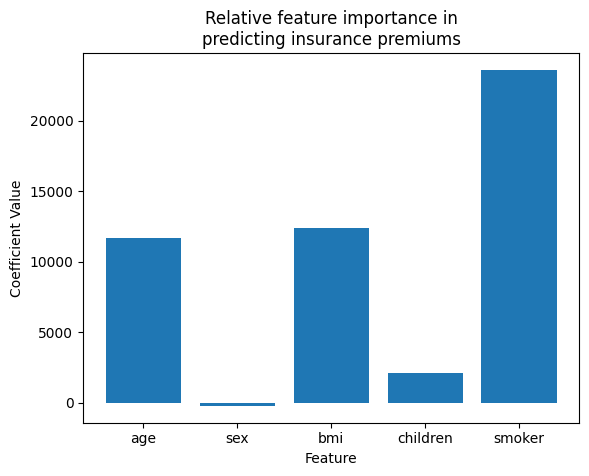

In [8]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# normalize the training data
scaler = MinMaxScaler()
X_train_scaled_ins = scaler.fit_transform(X_train_ins)
model = LinearRegression()

# Fit the model
model.fit(X_train_scaled_ins, y_train_ins)

# Derive coefficients
coefficients = model.coef_
feature_names = X_train_ins.columns

# Plot coefficients
plt.bar(feature_names, coefficients)
plt.title("Relative feature importance in\npredicting insurance premiums")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.show()

## Computing feature impact with logistic regression

Continuing work with the insurance company data, we'll now build you built a predictive model to identify whether an individual is a smoker or not. We'll then analyze the model to determine the relevant factors influencing smoking status. In such a scenario, this might help and insurance company assess risk more accurately and tailor insurance policies accordingly.

In [10]:
# set up the problem to predict probability of smoking
X_train_smoking = X_train_ins.iloc[:, :-1]
y_train_smoking = X_train_ins.iloc[:, -1]  # new target is smoking status
print(X_train_smoking.head(3))
y_train_smoking.value_counts()  # about 4x more non-smokers, so data is imbalanced but not severly

      age  sex     bmi  children
1160   43    0  34.580         1
902    26    1  27.265         3
1155   36    0  22.135         3


smoker
0    852
1    216
Name: count, dtype: int64

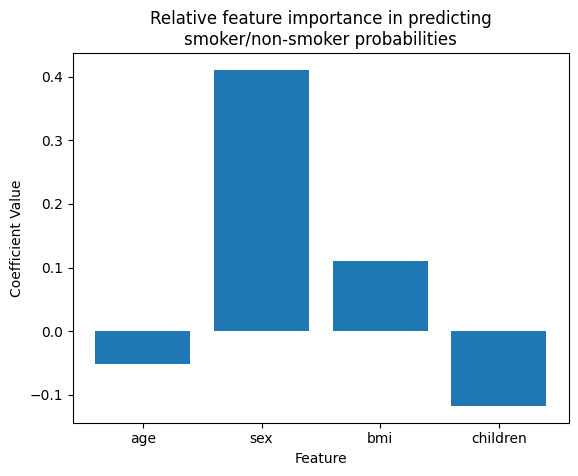

In [11]:
from sklearn.linear_model import LogisticRegression

# use the MinMaxScaler we created earlier
X_train_smoking_scaled = scaler.fit_transform(X_train_smoking)
# fit a logistic regression model on the training data
model = LogisticRegression()
model.fit(X_train_smoking_scaled, y_train_smoking)

# Derive coefficients
coefficients = model.coef_[0]
feature_names = X_train_smoking.columns

# Plot coefficients
plt.bar(feature_names, coefficients)
plt.title("Relative feature importance in predicting\nsmoker/non-smoker probabilities")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.show()

Looks like being a man increases the probability of being a smoker while children decrease the probability of being a smoker. These make sense intuitively.

## Computing feature importance with decision trees

We'll now build a decision tree classifier to identify patients at risk of heart disease using the heart disease dataset. This time, we'll explain the model by analyzing feature importance to determine the key factors for predicting heart disease. This could enabled more targeted healthcare interventions.

In [12]:
df_heart = pd.read_csv('./data/heart.csv')
# rename cols to something more descriptive to lay people
df_heart = df_heart.rename(columns={'cp': 'chest_pain_type',
                                    'trestbps': 'resting_blood_pressure',
                                    'chol': 'serum_cholesterol_mg_dl',
                                    'fbs': 'fasting_blood_sugar_gt_120_mg_dl',
                                    'restecg': 'resting_ecg_results',
                                    'thalach': 'max_heart_rate_achieved',
                                    'exang': 'exercise_induced_angina',
                                    'oldpeak': 'st_depression',
                                    'slope': 'st_slope',
                                    'ca': 'number_of_major_vessels',
                                    'thal': 'thalassemia'})
print(df_heart.shape)
df_heart.head()

(1025, 14)


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol_mg_dl,fasting_blood_sugar_gt_120_mg_dl,resting_ecg_results,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,number_of_major_vessels,thalassemia,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


target
1    427
0    393
Name: count, dtype: int64


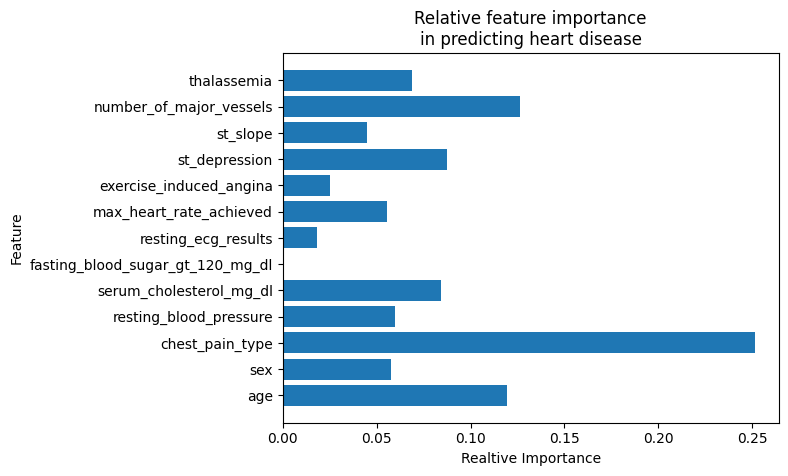

In [14]:
# separate features and target
X = df_heart.iloc[:, :-1]
y = df_heart.iloc[:, -1]
# partition into 80/20 train/test split
X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(X, y, test_size=0.2, random_state=711)
print(y_train_heart.value_counts())  # well-balanced

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_heart, y_train_heart)

# Derive feature importances
feature_importances = model.feature_importances_
feature_names = X_train_heart.columns

# Plot the feature importances
plt.barh(X_train_heart.columns, feature_importances)
plt.title("Relative feature importance\nin predicting heart disease")
plt.xlabel("Realtive Importance")
plt.ylabel("Feature")
plt.show()

## Computing feature importance with random forests

Next, we'll developed a random forest classifier that classifies individuals according to their **income levels**. After this, we'll explain the model by analyzing feature importance to determine the key factors for predicting income, enabling more targeted market segmentation and improving strategic decision-making.

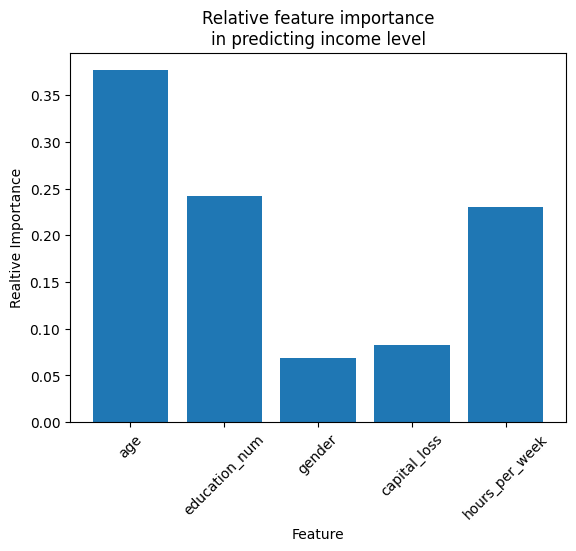

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_inc, y_train_inc)

# Derive feature importances
feature_importances = model.feature_importances_

# Plot the feature importances
plt.bar(X_train_inc.columns, feature_importances)
plt.title("Relative feature importance\nin predicting income level")
plt.ylabel("Realtive Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.show()

<img src="./graphics/jazz_group.png"></img>




## Kernel explainer for MLPRegressor (Multi-Layer Perceptron Regressor aka Neural Network)

Neural networks are a class of machine learning models that have been used in the context of supervised, unsupervised and reinforcement learning many years before becoming the foundation for most of the AI applications used today. These are popular models because they are flexible and can be quite powerful when designed and trained properly.

One of the main drawbacks of neural networks is that they are understandably treated as a ***black box*** because the results they generate are not intrinsically explainable.

We'll start exploring how to make the results of a neural network (NN) more explainable by:

1. employing ***permutation importance***
2. using a ***SHAP Kernel Explainer*** and
3. comparing neural network results (implemented with an `MLPRegressor`) with a ***logistic regression model***

We'll train the NN on a heart disease datasets data and use these results to critically assess how different features impact the model's predictions and verify these insights against our existing understanding of the dataset.

## Datasets

### Heart Disease

The first 1025 rows of the kaggle [Heart Disease Prediction Dataset](https://www.kaggle.com/datasets/iamcaano/heart-disease-prediction-dataset?resource=download) [1] were extracted for this analysis.

Column Descriptions:
+ `age` - Age of the patient (years)
+ `sex` - Sex (1 = male, 0 = female)
+ `cp` - Chest pain type (0–3), renamed to `chest_pain_type`
+ `trestbps` - Resting blood pressure (mm Hg), renamed to `resting_blood_pressure`
+ `chol` - Serum cholesterol (mg/dl), **NOT USED**
+ `fbs` - Fasting blood sugar > 120 mg/dl (1 = true, 0 = false), **NOT USED**
+ `restecg` - Resting electrocardiographic results (0–2), renamed to `resting_ecg_results`
+ `thalach` - Maximum heart rate achieved, **NOT USED**
+ `exang` - Exercise-induced angina (1 = yes, 0 = no), **NOT USED**
+ `oldpeak` - ST depression induced by exercise relative to rest, **NOT USED**
+ `slope` - Slope of the peak exercise ST segment (0–2), **NOT USED**
+ `ca` - Number of major vessels (0–3) colored by fluoroscopy, **NOT USED**
+ `thal` - Thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect), renamed to `thalassemia`
+ `target` - Diagnosis of heart disease (1 = present, 0 = absent)


### Admissions

TODO

In [ ]:
df_heart = pd.read_csv('./data/heart.csv')
# take the first 1025 rows
df_heart = df_heart.iloc[:1025]
# take the columns described above
relevant_cols = ['age', 'sex', 'cp', 'trestbps', 'restecg', 'thal', 'target']
df_heart = df_heart.loc[:, relevant_cols]
print(df_heart.shape)
# rename the columns as described above
df_heart = df_heart.rename(columns={'cp': 'chest_pain_type',
                                    'trestbps': 'resting_blood_pressure',
                                    'restecg': 'resting_ecg_results',
                                    'thal': 'thalassemia'})
print(df_heart.columns)
df_heart.head()

## Permutation importance for MLPClassifier

We'll now use permutation importance to identify which features are most impactful in predicting heart disease with an MLPClassifier. The graphic below describes the basic idea of how ***permutation importance*** works:

<img src="./graphics/permutation_importance.png"></img>

In [ ]:
# features
features = ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
            'resting_ecg_results', 'thalassemia']
X = df_heart.loc[:, features]
# target
y = df_heart['target']

In [ ]:
from sklearn.inspection import permutation_importance
# increase max_iter to ensure convergence
model = MLPClassifier(hidden_layer_sizes=(10), max_iter=1000, random_state=1)
model.fit(X, y)

# Compute the permutation importance
result = permutation_importance(model, X, y, n_repeats=10, random_state=1)

# Plot feature importances
fig1, ax1 = plt.subplots()
ax1.barh(X.columns, result.importances_mean)
ax1.set_title("NN Permutation Importance of Features - kaggle Heart Disease Data")
ax1.set_xlabel("Feature Importance")
plt.xticks(rotation=45)
plt.show()

## Coefficients vs. permutation importance

Next, we will compare the patterns identified by permutation importance with the model coefficients from a logistic regression trained on the heart disease dataset. A helper `function plot_importances()` is implemented to plot importances on the same plot.

X containing the features and y containing the labels, and the logistic regression model have been pre-loaded for you. matplotlib.pyplot has been imported as plt.

In [ ]:
import numpy as np

def plot_importances(coefficients,  perm_importances):
    features = X.columns  

    x = np.arange(len(features))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax1 = plt.subplots()

    # Plotting coefficients on the primary y-axis
    rects1 = ax1.bar(x - width/2, np.abs(coefficients), width, label='Coefficients', color='b')
    ax1.set_ylabel('Coefficient Magnitude', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_xticks(x)
    ax1.set_xticklabels(features, rotation=45)
    
    # Creating a secondary y-axis for permutation importances
    ax2 = ax1.twinx()
    rects2 = ax2.bar(x + width/2, perm_importances, width, label='Permutation Importance', color='g')
    ax2.set_ylabel('Permutation Importance', color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    # Adding title and adjusting layout
    ax1.set_title('Logistic Regression Coefficients vs. Permutation Importance')
    fig.tight_layout()

    # Adding legends outside the plot
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    # Placing the legend to the right outside of the plot
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(2, 1), borderaxespad=0.)

    # Adjusting the layout to avoid overlap
    plt.subplots_adjust(right=0.8)  # Allows space for the legend on the right

    plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

# train a logistic regression model
log_reg_model = LogisticRegression()
log_reg_model.fit(X, y)

In [ ]:
# Extract and store model coefficients
coefficients = log_reg_model.coef_[0]

# Compute permutation importance on the test set
perm_importance = permutation_importance(log_reg_model, X, y, n_repeats=20, random_state=1)

# Compute the average permutation importance
avg_perm_importance = perm_importance.importances_mean

plot_importances(coefficients, avg_perm_importance)

The permuation importance is significantly different from the logistic regression coefficients...

In [ ]:
# import seaborn as sns
# import shap
# # read and take init look at the data
# df_ads = pd.read_csv('./data/Admission_Predict_Ver1.1.csv')
# print(df_ads.columns)
# df_ads.info()  # looks like 2 LOR values are missing...
# # df_ads.head()  # first 4 rows identical to kaggle dataset at
#                  # https://www.kaggle.com/datasets/mohansacharya/graduate-admissions
# df_ads.tail()

In [ ]:
# from sklearn.model_selection import train_test_split

# features = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
#             'LOR ', 'CGPA', 'Research', 'Chance of Admit ']

# X_raw = df_ads.loc[:, features]
# y_raw = df_ads.loc[:, ]
# X_train_unscaled = train_test_split()

In [ ]:
# # Create a SHAP Kernel Explainer
# explainer = shap.KernelExplainer(
#     model.predict,
#     shap.kmeans(X, 10)
# )

# # Calculate SHAP values
# shap_values = explainer.shap_values(X)

# # Calculate mean absolute SHAP values
# mean_abs_shap = np.abs(shap_values).mean(axis=0)

# plt.bar(X.columns, mean_abs_shap)
# plt.title('Mean Absolute SHAP Values for MLPRegressor')
# plt.xticks(rotation=45)
# plt.show()

## Kernel explainer for MLPClassifier

Neural networks can be very accurate, but understanding their decisions can be challenging due to complexity. Now, we'll leverage the SHAP Kernel Explainer to interpret an `MLPClassifier` trained on the adult income dataset. We will will explore which of the three features: age, education, or hours worked per week is most important for predicting income according to this model.

X containing the predictors and y containing the admission decisions, along with the pre-trained MLPClassifier model, have been pre-loaded for you.

In [ ]:
# # Create a SHAP Kernel Explainer
# explainer = shap.KernelExplainer(
#     model.predict_proba,
#     shap.kmeans(X, 10)
# )

# # Calculate SHAP values
# shap_values = explainer.shap_values(X)

# # Calculate mean absolute SHAP values
# mean_abs_shap = np.abs(shap_values[:, :,1]).mean(axis=0)

# plt.bar(X.columns, mean_abs_shap)
# plt.title('Mean Absolute SHAP Values for MLPClassifier')
# plt.xticks(rotation=45)
# plt.show()

## SHAP vs. model-specific approaches

Let's compare the explanatory power of SHAP values from a Kernel Explainer with the logistic regression coefficients, both trained on the income dataset. We'll use the `plot_importances()` function implemented earlier so we can see both importances on the same plot.



In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("mastmustu/income", output_dir='./data/income_data')

# print("Path to dataset files:", path)

In [ ]:
# path = kagglehub.dataset_download("uciml/adult-census-income", output_dir='./data/uci_income_data')
# print("Path to dataset files:", path)

# Using LIME for interpretting regressors locally

## Model insurance costs using KNN with the following features:

+ `age`
+ `sex`
+ `BMI`
+ `number of children`
+ `smoking status.`

Original data source: UNKNOWN (downloaded from DataCamp [here](https://assets.datacamp.com/production/repositories/6745/datasets/c50a08e4b83daca7514f47d1baab1dcc67f38ee6/insurance.csv))

In [ ]:
# train a KNN model using the entire dataset, because we are accessing how each feature affects predictions
df_ins = pd.read_csv('./data/insurance.csv')
# print(df_ins.shape)
# print(df_ins.columns)
df_ins.info()
df_ins.head()

In [ ]:
from sklearn.neighbors import KNeighborsRegressor as KNNReg

knn_reg = KNNReg()
# drop the rows with missing values
df_no_miss = df_ins[~df_ins['bmi'].isna()]

X = df_no_miss.iloc[:, :-1]
y = df_no_miss.iloc[:, -1]

# https://share.google/aimode/jNHLfUaTEEYDfFc9I
knn_reg.fit(X.values, y)

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# https://share.google/aimode/jNHLfUaTEEYDfFc9I
# predict_fn = lambda x: knn_reg.predict(pd.DataFrame(x, columns=X.columns))

sample_data_point = X.iloc[2, :]

# Create the explainer
explainer = LimeTabularExplainer(
    X.values,
    feature_names=X.columns,
    mode='regression'
)

# Generate the explanation
exp = explainer.explain_instance(
    sample_data_point.values,
    knn_reg.predict
)

# Display the explanation
exp.as_pyplot_figure()
plt.show()

## Model heart disease using KNN with the following features:

+ `age`
+ `sex`
+ `chest_pain_type`
+ `resting_blood_pressure`


In [ ]:
# use heart data from earlier, but take the above mentioned columns
df_heart_ascp = df_heart.loc[:, ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'target']]
df_heart_ascp.info() # no missing values
df_heart_ascp.head()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier as KNNClass

X = df_heart_ascp.iloc[:, :-1]
y = df_heart_ascp.iloc[:, -1]

knn_class = KNNClass()
knn_class.fit(X.values, y)

In [ ]:
# explain a sample classification prediction
sample_data_point = X.iloc[2, :]

# Create the explainer
explainer = LimeTabularExplainer(
    X.values,
    feature_names=X.columns,
    mode='classification'
)

# Generate the explanation
exp = explainer.explain_instance(
    sample_data_point.values,
    knn_class.predict_proba
)

# Display the explanation
exp.as_pyplot_figure()
plt.show()

# References

1. Heart Disease Data: [https://www.kaggle.com/datasets/iamcaano/heart-disease-prediction-dataset?resource=download](https://www.kaggle.com/datasets/iamcaano/heart-disease-prediction-dataset?resource=download)
2. Income: **TODO**
3. Admissions Data: [https://www.kaggle.com/datasets/mohansacharya/graduate-admissions/data?select=Admission_Predict_Ver1.1.csv](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions/data?select=Admission_Predict_Ver1.1.csv)